In [1]:
import os, sys, re, time, json, random, pickle, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score,
                             precision_recall_fscore_support,
                             classification_report,
                             confusion_matrix,
                             roc_auc_score)

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Fix every RNG so re-runs are reproducible.
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)
sns.set_style("whitegrid")

HERE        = Path.cwd()
REVIEWS_CSV = HERE / "dataset/amazon_electronics_500k.csv"
META_CSV    = HERE / "dataset/amazon_electronics_meta.csv"
FIG_DIR     = HERE / "figures";   FIG_DIR.mkdir(exist_ok=True)
ART_DIR     = HERE / "artifacts"; ART_DIR.mkdir(exist_ok=True)

if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

for pkg, path in [("stopwords","corpora/stopwords"),
                  ("wordnet","corpora/wordnet"),
                  ("omw-1.4","corpora/omw-1.4")]:
    try:    nltk.data.find(path)
    except LookupError: nltk.download(pkg, quiet=True)

print(f"Working dir   : {HERE}")
print(f"Torch device  : {DEVICE}")
print(f"Reviews CSV   : {REVIEWS_CSV.exists()}   {REVIEWS_CSV}")
print(f"Metadata CSV  : {META_CSV.exists()}   {META_CSV}")


/Users/ace/Documents/artificial-intelligence-coursework/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Working dir   : /Users/ace/Documents/artificial-intelligence-coursework
Torch device  : mps
Reviews CSV   : True   /Users/ace/Documents/artificial-intelligence-coursework/dataset/amazon_electronics_500k.csv
Metadata CSV  : True   /Users/ace/Documents/artificial-intelligence-coursework/dataset/amazon_electronics_meta.csv


## Loading the data


In [2]:
t0 = time.time()

# Explicit dtypes are faster and use ~half the RAM versus auto-detect.
reviews = pd.read_csv(
    REVIEWS_CSV,
    dtype={
        "rating":            "float32",
        "helpful_vote":      "int32",
        "verified_purchase": "string",
        "asin":              "string",
        "parent_asin":       "string",
        "user_id":           "string",
    },
)
meta = pd.read_csv(META_CSV)

print(f"reviews: {reviews.shape}   memory={reviews.memory_usage(deep=True).sum()/1e6:,.0f} MB")
print(f"meta   : {meta.shape}     memory={meta.memory_usage(deep=True).sum()/1e6:,.0f} MB")
print(f"loaded in {time.time()-t0:,.1f}s")

reviews.head(3)


reviews: (500000, 9)   memory=390 MB
meta   : (177727, 10)     memory=442 MB
loaded in 4.1s


,rating,title,text,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,3.0,Smells like gasoline! Going back!,First & most offensive: they reek of gasoline so if you are sensitive/allergic to petroleum products like I am you w...,B083NRGZMM,B083NRGZMM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1658185117948,0,True
1,1.0,Didn’t work at all lenses loose/broken.,"These didn’t work. Idk if they were damaged in shipping or what, but the lenses were loose or something. I could see...",B07N69T6TM,B07N69T6TM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1592678549731,0,True
2,5.0,Excellent!,I love these. They even come with a carry case and several sizes of ear bud inserts. Thank heaven! I get ear pain f...,B01G8JO5F2,B01G8JO5F2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1523093017534,0,True


In [3]:
print("Missing values in reviews:")
print(reviews.isna().sum().to_string())
print()

print("Rating distribution (counts):")
print(reviews["rating"].value_counts().sort_index().to_string())
print()

print(f"unique users   : {reviews['user_id'].nunique():,}")
print(f"unique products: {reviews['parent_asin'].nunique():,}")


Missing values in reviews:
rating                 0
title                 85
text                 191
asin                   0
parent_asin            0
user_id                0
timestamp              0
helpful_vote           0
verified_purchase      0

Rating distribution (counts):
rating
1.0     42860
2.0     23495
3.0     35783
4.0     71173
5.0    326689

unique users   : 94,898
unique products: 177,727


## Exploratory Data Analysis


### Rating distribution

On Amazon, people who love or hate a product leave reviews; those who felt neutral stay quiet, so the distribution is J-shaped. This is what forces stratified splits and class-balanced loss later.


rating
1.0     8.57
2.0     4.70
3.0     7.16
4.0    14.23
5.0    65.34


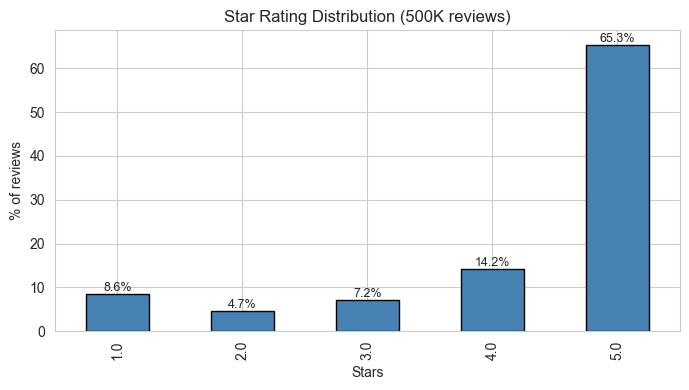

In [4]:
rating_pct = (reviews["rating"].value_counts().sort_index() / len(reviews) * 100)
print(rating_pct.round(2).to_string())

fig, ax = plt.subplots(figsize=(7, 4))
rating_pct.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
ax.set(title="Star Rating Distribution (500K reviews)",
       xlabel="Stars", ylabel="% of reviews")

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR/"01_rating_distribution.png", dpi=110)
plt.show()


### Review length

Used to choose where to cap text for BERT (512-token limit). Plot is clipped at 200 words for readability.


Word-count percentiles:
0.10      4.0
0.50     28.0
0.90    131.0
0.99    439.0


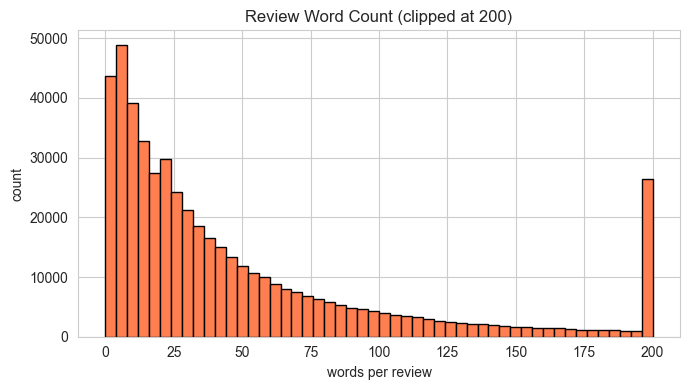

In [5]:
reviews["text"] = reviews["text"].fillna("").astype(str)
reviews["text_len"] = reviews["text"].str.split().str.len()

print("Word-count percentiles:")
print(reviews["text_len"].quantile([0.10, 0.50, 0.90, 0.99]).round(0).to_string())

# Clip at 200 so the long tail does not squash the chart.
fig, ax = plt.subplots(figsize=(7, 4))
reviews["text_len"].clip(upper=200).hist(bins=50, ax=ax,
                                         color="coral", edgecolor="black")
ax.set(title="Review Word Count (clipped at 200)",
       xlabel="words per review", ylabel="count")
plt.tight_layout()
plt.savefig(FIG_DIR/"02_review_length.png", dpi=110)
plt.show()


### Top product categories

If one sub-category dominates, that becomes a limitation worth reporting.


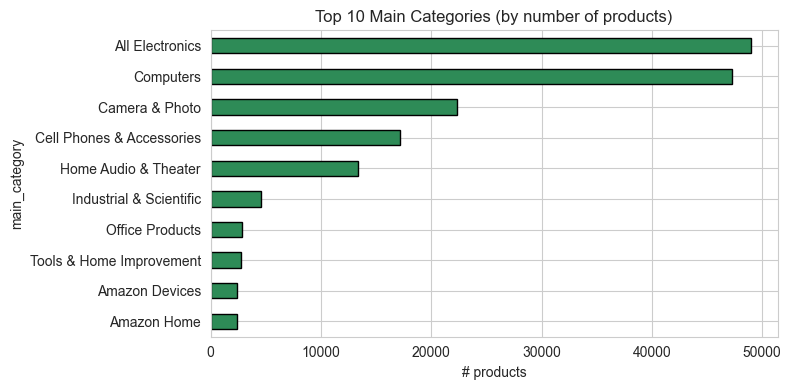

main_category
All Electronics              48948
Computers                    47235
Camera & Photo               22327
Cell Phones & Accessories    17163
Home Audio & Theater         13363
Industrial & Scientific       4542
Office Products               2799
Tools & Home Improvement      2771
Amazon Devices                2377
Amazon Home                   2344


In [6]:
if "main_category" in meta.columns:
    top = meta["main_category"].value_counts().head(10)

    fig, ax = plt.subplots(figsize=(8, 4))
    top[::-1].plot(kind="barh",
                   color="seagreen", ax=ax, edgecolor="black")
    ax.set(title="Top 10 Main Categories (by number of products)",
           xlabel="# products")
    plt.tight_layout()
    plt.savefig(FIG_DIR/"03_top_categories.png", dpi=110)
    plt.show()

    print(top.to_string())


### User and product activity

Most users review once, a few review hundreds. Same long-tail pattern for products. Users with 1–3 interactions are the cold-start case.


Users  with >=5 reviews : 28,282  (29.8% of users)
Items  with >=5 reviews : 17,732  (10.0% of items)


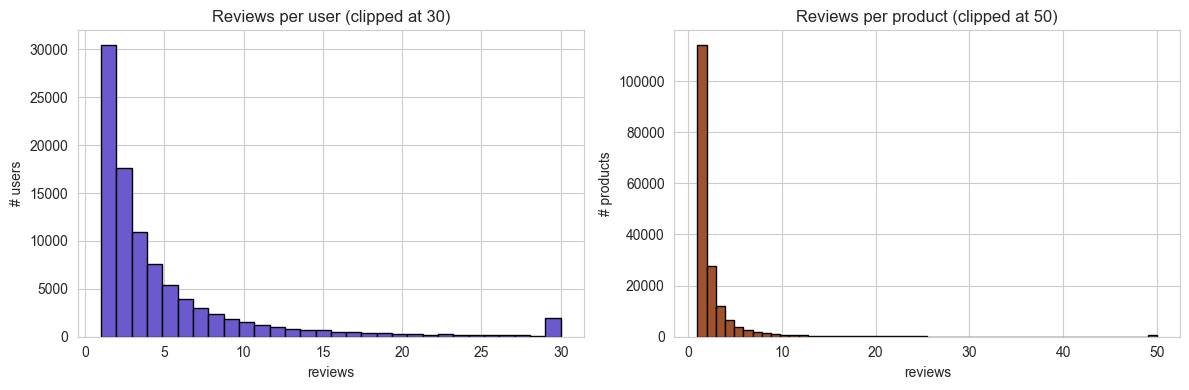

In [7]:
user_cnt = reviews.groupby("user_id").size()
item_cnt = reviews.groupby("parent_asin").size()

print(f"Users  with >=5 reviews : {(user_cnt>=5).sum():,}  "
      f"({(user_cnt>=5).mean()*100:.1f}% of users)")
print(f"Items  with >=5 reviews : {(item_cnt>=5).sum():,}  "
      f"({(item_cnt>=5).mean()*100:.1f}% of items)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
user_cnt.clip(upper=30).hist(bins=30, ax=axes[0],
                             color="slateblue", edgecolor="black")
axes[0].set(title="Reviews per user (clipped at 30)",
            xlabel="reviews", ylabel="# users")
item_cnt.clip(upper=50).hist(bins=50, ax=axes[1],
                             color="sienna", edgecolor="black")
axes[1].set(title="Reviews per product (clipped at 50)",
            xlabel="reviews", ylabel="# products")
plt.tight_layout()
plt.savefig(FIG_DIR/"04_activity.png", dpi=110)
plt.show()


### Matrix sparsity

Density of the user × item rating matrix. Real recommender datasets are usually >99.9% sparse - this is what motivates adding sentiment as extra signal.


In [8]:
n_users   = reviews["user_id"].nunique()
n_items   = reviews["parent_asin"].nunique()
n_ratings = len(reviews)
density   = n_ratings / (n_users * n_items) * 100

print(f"users    = {n_users:,}")
print(f"items    = {n_items:,}")
print(f"ratings  = {n_ratings:,}")
print(f"density  = {density:.4f} %   (sparsity = {100-density:.4f} %)")


users    = 94,898
items    = 177,727
ratings  = 500,000
density  = 0.0030 %   (sparsity = 99.9970 %)


## Text preprocessing

Regex removal of HTML/URLs, lowercasing, stopword removal (NLTK English), WordNet lemmatisation.


In [9]:
STOPS       = set(stopwords.words("english"))
LEMMA       = WordNetLemmatizer()
HTML_RE     = re.compile(r"<[^>]+>")
URL_RE      = re.compile(r"http\S+|www\.\S+")
NONALPHA_RE = re.compile(r"[^a-z\s]")

def clean_review(text: str) -> str:
    text = text.lower()
    text = HTML_RE.sub(" ", text)
    text = URL_RE.sub(" ", text)
    text = NONALPHA_RE.sub(" ", text)
    tokens = [LEMMA.lemmatize(tok)
              for tok in text.split()
              if tok not in STOPS and len(tok) > 2]
    return " ".join(tokens)

demo = "Great product!!! <b>Loved</b> it. Runs fast. https://example.com Would buy again."
print("RAW   :", demo)
print("CLEAN :", clean_review(demo))


RAW   : Great product!!! <b>Loved</b> it. Runs fast. https://example.com Would buy again.
CLEAN : great product loved run fast would buy


In [10]:
reviews["title"] = reviews["title"].fillna("").astype(str)
reviews["raw_text"] = (reviews["title"] + " " + reviews["text"]).str.strip()

before = len(reviews)
reviews = reviews[reviews["raw_text"].str.len() > 0].reset_index(drop=True)
print(f"dropped {before - len(reviews):,} empty-text rows   "
      f"({len(reviews):,} remaining)")


dropped 40 empty-text rows   (499,960 remaining)


In [11]:
CACHE = ART_DIR / "clean_text.pkl"

if CACHE.exists():
    reviews["clean_text"] = pickle.loads(CACHE.read_bytes())
    print(f"loaded cached clean_text ({len(reviews):,} rows)")
else:
    t0 = time.time()
    reviews["clean_text"] = [clean_review(t)
                             for t in tqdm(reviews["raw_text"], desc="cleaning")]
    CACHE.write_bytes(pickle.dumps(reviews["clean_text"].to_list()))
    print(f"cleaned in {time.time()-t0:,.1f}s   (cached)")

reviews[["rating","raw_text","clean_text"]].head(3)


cleaning:   0%|          | 0/499960 [00:00<?, ?it/s]

cleaned in 37.6s   (cached)


,rating,raw_text,clean_text
0,3.0,Smells like gasoline! Going back! First & most offensive: they reek of gasoline so if you are sensitive/allergic to ...,smell like gasoline going back first offensive reek gasoline sensitive allergic petroleum product like want pas seco...
1,1.0,"Didn’t work at all lenses loose/broken. These didn’t work. Idk if they were damaged in shipping or what, but the len...",work lens loose broken work idk damaged shipping lens loose something could see half lens edge frame rest missing lo...
2,5.0,Excellent! I love these. They even come with a carry case and several sizes of ear bud inserts. Thank heaven! I get...,excellent love even come carry case several size ear bud insert thank heaven get ear pain smallest bud fit great als...


### Sentiment labels from star ratings

1–2★ → negative, 3★ → neutral, 4–5★ → positive. Standard literature mapping; gives free labels at the cost of some noise.


In [12]:
def stars_to_sentiment(r: float) -> str:
    if r <= 2: return "negative"
    if r == 3: return "neutral"
    return "positive"

reviews["sentiment"] = reviews["rating"].apply(stars_to_sentiment)

print((reviews["sentiment"].value_counts(normalize=True)*100).round(2).to_string())


sentiment
positive    79.57
negative    13.27
neutral      7.16


## Subsample for modelling

Filter to users and items with ≥5 interactions (so CF has something to learn from), then cap at 200K rows so BERT fine-tuning fits in reasonable time on one laptop.


In [13]:
MIN_INT  = 5
MAX_ROWS = 200_000

u_keep = user_cnt[user_cnt >= MIN_INT].index
i_keep = item_cnt[item_cnt >= MIN_INT].index

filtered = reviews[reviews["user_id"].isin(u_keep)
                   & reviews["parent_asin"].isin(i_keep)].reset_index(drop=True)

print(f"after >={MIN_INT}-interaction filter: {len(filtered):,} rows")
print(f"  users = {filtered['user_id'].nunique():,}")
print(f"  items = {filtered['parent_asin'].nunique():,}")

if len(filtered) > MAX_ROWS:
    filtered = filtered.sample(MAX_ROWS, random_state=SEED).reset_index(drop=True)
    print(f"sampled to {len(filtered):,} rows for tractable training")

print()
print("sentiment distribution on modelling set:")
print((filtered['sentiment'].value_counts(normalize=True)*100).round(2).to_string())


after >=5-interaction filter: 194,221 rows
  users = 27,986
  items = 17,713

sentiment distribution on modelling set:
sentiment
positive    82.01
negative    11.18
neutral      6.82


## Train/test split and TF-IDF features

80/20 stratified split. Stratifying preserves class proportions in both halves - important because the rating distribution is heavily skewed toward positive. Combined with `class_weight="balanced"` during training, this gives honest evaluation and honest learning on the minority classes.


In [14]:
X_text = filtered["clean_text"].values
y      = filtered["sentiment"].values

# stratify=y keeps each class proportion in both halves.
X_tr_txt, X_te_txt, y_tr, y_te = train_test_split(
    X_text, y, test_size=0.2, random_state=SEED, stratify=y)

print(f"train: {len(X_tr_txt):,}   test: {len(X_te_txt):,}")


train: 155,376   test: 38,845


### TF-IDF

Each review becomes a sparse weighted bag-of-words. Config: `max_features=8000`, `ngram_range=(1,2)`, `min_df=5`, `sublinear_tf=True`.


In [15]:
tfidf = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 2),
    min_df=5,
    sublinear_tf=True,
)

t0 = time.time()
# fit_transform on TRAIN, transform on TEST -> avoid vocabulary leakage.
X_tr = tfidf.fit_transform(X_tr_txt)
X_te = tfidf.transform(X_te_txt)
print(f"TF-IDF fit+transform in {time.time()-t0:,.1f}s")

print(f"train matrix: {X_tr.shape}   test matrix: {X_te.shape}")
print(f"sample vocab: {list(tfidf.get_feature_names_out()[:10])}")


TF-IDF fit+transform in 7.9s
train matrix: (155376, 8000)   test matrix: (38845, 8000)
sample vocab: ['aaa', 'aaa battery', 'abc', 'ability', 'able', 'able connect', 'able find', 'able get', 'able hear', 'able plug']


## Sentiment classification

Four models on the same test set so results are directly comparable.


In [16]:
def eval_classifier(name, y_true, y_pred, y_proba=None, classes=None):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0)

    auc = np.nan
    if y_proba is not None and classes is not None:
        try:
            y_dummy = pd.get_dummies(y_true).reindex(columns=classes, fill_value=0).values
            auc = roc_auc_score(y_dummy, y_proba, multi_class="ovr", average="macro")
        except Exception:
            pass

    print(f"{name:>22s} | acc={acc:.4f}  P={prec:.4f}  R={rec:.4f}  F1={f1:.4f}  AUC={auc:.4f}")

    return dict(model=name, accuracy=acc, precision=prec, recall=rec, f1=f1, auc=auc)

sent_results = []


### Logistic Regression

Fast linear baseline. `class_weight="balanced"` corrects for the rating-distribution imbalance.


In [17]:
t0 = time.time()

lr = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    C=1.0,
    n_jobs=-1,
    random_state=SEED,
)

lr.fit(X_tr, y_tr)
lr_proba = lr.predict_proba(X_te)
lr_pred  = lr.predict(X_te)
lr_secs  = time.time() - t0

res = eval_classifier("LogReg+TFIDF", y_te, lr_pred, lr_proba, classes=list(lr.classes_))
res["train_sec"] = round(lr_secs, 1); sent_results.append(res)


          LogReg+TFIDF | acc=0.8196  P=0.6148  R=0.7181  F1=0.6445  AUC=0.9162


### Linear SVM

Maximum-margin linear classifier. `LinearSVC` is fast on TF-IDF but does not produce probabilities.


In [18]:
t0 = time.time()

svm = LinearSVC(
    C=1.0,
    class_weight="balanced",
    max_iter=4000,
    random_state=SEED,
)

svm.fit(X_tr, y_tr)
svm_pred = svm.predict(X_te)
svm_secs = time.time() - t0

# LinearSVC has no predict_proba -> AUC stays NaN.
res = eval_classifier("LinearSVM+TFIDF", y_te, svm_pred, None, None)
res["train_sec"] = round(svm_secs, 1); sent_results.append(res)


       LinearSVM+TFIDF | acc=0.8714  P=0.6539  R=0.6814  F1=0.6668  AUC=nan


### Naive Bayes

Classical NLP baseline. Word-independence assumption is wrong but the model stays competitive on text.


In [19]:
t0 = time.time()

nb = MultinomialNB()
nb.fit(X_tr, y_tr)

nb_proba = nb.predict_proba(X_te)
nb_pred  = nb.predict(X_te)
nb_secs  = time.time() - t0

res = eval_classifier("NaiveBayes+TFIDF", y_te, nb_pred, nb_proba, classes=list(nb.classes_))
res["train_sec"] = round(nb_secs, 1); sent_results.append(res)


      NaiveBayes+TFIDF | acc=0.8737  P=0.7620  R=0.5321  F1=0.5703  AUC=0.9128


### DistilBERT - fine-tuned

~40% smaller and faster than BERT with ~97% of its accuracy. Fine-tuned on a stratified 10K subset for 1 epoch (max length 128, batch size 32, AdamW @ 5e-5). Manual training loop instead of HuggingFace `Trainer` due to `accelerate` version incompatibility.


In [20]:
BERT_MODEL = "distilbert-base-uncased"
BERT_TRAIN = 10_000
BERT_TEST  = 2_500
MAX_LEN    = 128

label2id = {"negative": 0, "neutral": 1, "positive": 2}
id2label = {v: k for k, v in label2id.items()}

# Stratified subsample so rare classes (neutral, negative) survive.
rng = np.random.RandomState(SEED)

def stratified_idx(labels, n):
    labels    = np.asarray(labels)
    cls, cnts = np.unique(labels, return_counts=True)
    per_cls = {c: max(1, int(round(n * cnts[i] / len(labels))))
               for i, c in enumerate(cls)}
    picked = []
    for c in cls:
        idx = np.where(labels == c)[0]
        picked.extend(rng.choice(idx, size=min(per_cls[c], len(idx)), replace=False))
    rng.shuffle(picked)
    return picked[:n]

tr_idx = stratified_idx(y_tr, BERT_TRAIN)
te_idx = stratified_idx(y_te, BERT_TEST)
Xb_tr = [X_tr_txt[i] for i in tr_idx]; yb_tr = [label2id[y_tr[i]] for i in tr_idx]
Xb_te = [X_te_txt[i] for i in te_idx]; yb_te = [label2id[y_te[i]] for i in te_idx]
print(f"BERT subset: train={len(Xb_tr):,}  test={len(Xb_te):,}")

tok = AutoTokenizer.from_pretrained(BERT_MODEL)

class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tok, max_len):
        self.texts, self.labels, self.tok, self.max_len = texts, labels, tok, max_len
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, i):
        enc = self.tok(self.texts[i], truncation=True, max_length=self.max_len,
                       padding="max_length", return_tensors="pt")
        return {
            "input_ids":      enc["input_ids"][0],
            "attention_mask": enc["attention_mask"][0],
            "labels":         torch.tensor(self.labels[i], dtype=torch.long),
        }

ds_tr = ReviewDataset(Xb_tr, yb_tr, tok, MAX_LEN)
ds_te = ReviewDataset(Xb_te, yb_te, tok, MAX_LEN)

model = AutoModelForSequenceClassification.from_pretrained(
    BERT_MODEL, num_labels=3, id2label=id2label, label2id=label2id).to(DEVICE)

# Manual training loop instead of HuggingFace Trainer due to accelerate version conflicts.
BATCH  = 32
EPOCHS = 1
LR     = 5e-5

dl_tr = DataLoader(ds_tr, batch_size=BATCH, shuffle=True)
dl_te = DataLoader(ds_te, batch_size=64, shuffle=False)

optim = torch.optim.AdamW(model.parameters(), lr=LR)

t0 = time.time()
model.train()
step = 0
for epoch in range(EPOCHS):
    running = 0.0
    for batch in tqdm(dl_tr, desc=f"epoch {epoch+1}"):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}

        out  = model(**batch)
        loss = out.loss

        optim.zero_grad()
        loss.backward()
        optim.step()

        running += loss.item()
        step    += 1
        if step % 50 == 0:
            print(f"  step {step:4d}  loss={loss.item():.4f}")

bert_secs = time.time() - t0
print(f"BERT fine-tuning: {bert_secs:,.1f}s")

model.eval()
all_logits, all_labels = [], []

with torch.no_grad():
    for batch in dl_te:
        labels = batch.pop("labels")
        batch  = {k: v.to(DEVICE) for k, v in batch.items()}
        out    = model(**batch)
        all_logits.append(out.logits.cpu())
        all_labels.append(labels)

bert_logits = torch.cat(all_logits).numpy()
y_true_bert = torch.cat(all_labels).numpy()
y_pred_bert = bert_logits.argmax(axis=-1)

acc  = accuracy_score(y_true_bert, y_pred_bert)
prec, rec, f1, _ = precision_recall_fscore_support(
    y_true_bert, y_pred_bert, average="macro", zero_division=0)

bert_proba = torch.softmax(torch.tensor(bert_logits), dim=-1).numpy()
try:
    bert_auc = roc_auc_score(
        pd.get_dummies(y_true_bert).reindex(columns=[0, 1, 2], fill_value=0).values,
        bert_proba, multi_class="ovr", average="macro")
except Exception:
    bert_auc = np.nan

print(f"DistilBERT(finetuned) | acc={acc:.4f}  P={prec:.4f}  R={rec:.4f}  F1={f1:.4f}  AUC={bert_auc:.4f}")

sent_results.append(dict(
    model="DistilBERT(finetuned)",
    accuracy=acc, precision=prec, recall=rec, f1=f1,
    auc=bert_auc, train_sec=round(bert_secs, 1)))


BERT subset: train=10,000  test=2,499


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


epoch 1:   0%|          | 0/313 [00:00<?, ?it/s]

  step   50  loss=0.4201
  step  100  loss=0.3521
  step  150  loss=0.3039
  step  200  loss=0.5728
  step  250  loss=0.6032
  step  300  loss=0.2878
BERT fine-tuning: 445.3s
DistilBERT(finetuned) | acc=0.8840  P=0.8498  R=0.5944  F1=0.5959  AUC=0.9102


                model  accuracy  precision  recall     f1    auc  train_sec
         LogReg+TFIDF    0.8196     0.6148  0.7181 0.6445 0.9162        3.8
      LinearSVM+TFIDF    0.8714     0.6539  0.6814 0.6668    NaN        4.1
     NaiveBayes+TFIDF    0.8737     0.7620  0.5321 0.5703 0.9128        0.2
DistilBERT(finetuned)    0.8840     0.8498  0.5944 0.5959 0.9102      445.3


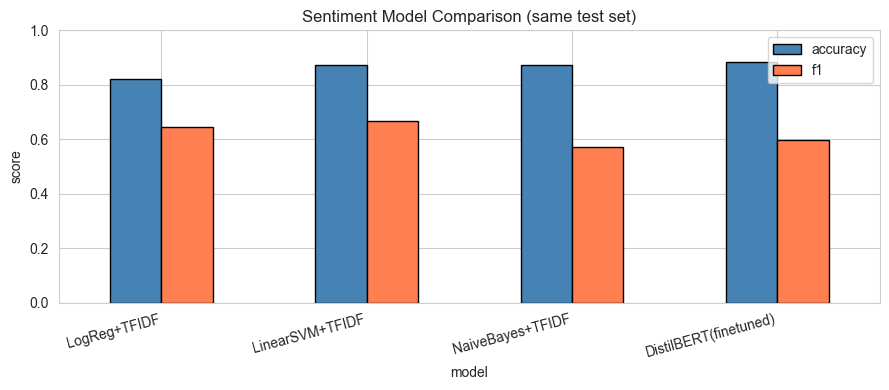

In [21]:
sent_df = pd.DataFrame(sent_results)[[
    "model", "accuracy", "precision", "recall", "f1", "auc", "train_sec"]]

sent_df.to_csv(ART_DIR/"sentiment_comparison.csv", index=False)
print(sent_df.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
sent_df.set_index("model")[["accuracy", "f1"]].plot(
    kind="bar", ax=ax, color=["steelblue", "coral"], edgecolor="black")
ax.set(title="Sentiment Model Comparison (same test set)",
       ylabel="score", ylim=(0, 1))
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR/"05_sentiment_models.png", dpi=110)
plt.show()


## Sentiment as a numeric feature

Use the LogReg model to score every review. `sent_score = P(positive) − P(negative)` lives in roughly `[-1, +1]` and is the signal we fuse with collaborative filtering.


In [22]:
# Reuse the trained tfidf vocabulary -> .transform, not fit_transform.
X_all = tfidf.transform(filtered["clean_text"].values)
proba_all = lr.predict_proba(X_all)

classes = list(lr.classes_)
ci_pos  = classes.index("positive")
ci_neg  = classes.index("negative")

# Signed score in roughly [-1, +1].
filtered["sent_score"] = (proba_all[:, ci_pos] - proba_all[:, ci_neg]).astype("float32")

print("sent_score summary:")
print(filtered["sent_score"].describe().round(4).to_string())
print()
print("example rows:")
print(filtered[["rating", "sentiment", "sent_score", "raw_text"]].head(3).to_string(index=False))


sent_score summary:
count    194221.0000
mean          0.4968
std           0.5734
min          -1.0000
25%           0.1543
50%           0.7578
75%           0.9560
max           1.0000

example rows:
 rating sentiment  sent_score                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

## Recommender - Matrix Factorisation

Biased MF implemented from scratch in PyTorch (the same algorithm `scikit-surprise`'s SVD uses internally; reimplemented here because of a NumPy 2.x ABI conflict with that library):

$$\hat r_{u,i} = \mu + b_u + b_i + \mathbf{p}_u \cdot \mathbf{q}_i$$

Trained with AdamW + L2 regularisation on the MPS / CUDA / CPU backend.


In [23]:
u_cat = pd.Categorical(filtered["user_id"])
i_cat = pd.Categorical(filtered["parent_asin"])
filtered["u_idx"] = u_cat.codes.astype(np.int64)
filtered["i_idx"] = i_cat.codes.astype(np.int64)

N_USERS = len(u_cat.categories)
N_ITEMS = len(i_cat.categories)
print(f"unique users = {N_USERS:,}   unique items = {N_ITEMS:,}")

def enhanced_rating(r, s, alpha):
    # Map sent_score [-1,1] -> [1,5], then convex-combine with the star rating.
    s_on_rating = 3.0 + 2.0 * s
    return (alpha * r + (1.0 - alpha) * s_on_rating).clip(1.0, 5.0)

RATING_COLS = {"baseline": "rating"}
for a in [0.3, 0.5, 0.7]:
    col = f"enh_{a}"
    filtered[col] = enhanced_rating(filtered["rating"], filtered["sent_score"], a).astype("float32")
    RATING_COLS[f"LR-sent a={a}"] = col

print("rating columns:", RATING_COLS)


unique users = 27,986   unique items = 17,713
rating columns: {'baseline': 'rating', 'LR-sent a=0.3': 'enh_0.3', 'LR-sent a=0.5': 'enh_0.5', 'LR-sent a=0.7': 'enh_0.7'}


In [24]:
n    = len(filtered)
rng  = np.random.RandomState(SEED)
perm = rng.permutation(n)

cut       = int(n * 0.8)
train_idx = perm[:cut]
test_idx  = perm[cut:]

print(f"train rows: {len(train_idx):,}   test rows: {len(test_idx):,}")


train rows: 155,376   test rows: 38,845


In [25]:
class MF(torch.nn.Module):
    """Biased matrix factorisation: r_hat = mu + b_u + b_i + p_u . q_i"""
    def __init__(self, n_users, n_items, k=50, mu=0.0):
        super().__init__()
        self.mu = torch.nn.Parameter(torch.tensor(float(mu)), requires_grad=False)
        self.P  = torch.nn.Embedding(n_users, k)
        self.Q  = torch.nn.Embedding(n_items, k)
        self.bu = torch.nn.Embedding(n_users, 1)
        self.bi = torch.nn.Embedding(n_items, 1)

        # Small std avoids exploding dot products at the start of training.
        torch.nn.init.normal_(self.P.weight, std=0.05)
        torch.nn.init.normal_(self.Q.weight, std=0.05)
        torch.nn.init.zeros_(self.bu.weight)
        torch.nn.init.zeros_(self.bi.weight)

    def forward(self, u, i):
        dot = (self.P(u) * self.Q(i)).sum(-1)
        return self.mu + self.bu(u).squeeze(-1) + self.bi(i).squeeze(-1) + dot


In [26]:
def train_mf(ratings_col, k=50, epochs=15, batch=8192, lr=0.01, wd=5e-4, verbose=False):
    r_full = filtered[ratings_col].values.astype("float32")
    u_full = filtered["u_idx"].values
    i_full = filtered["i_idx"].values

    r_tr = torch.tensor(r_full[train_idx], device=DEVICE)
    u_tr = torch.tensor(u_full[train_idx], device=DEVICE)
    i_tr = torch.tensor(i_full[train_idx], device=DEVICE)

    mu      = float(r_tr.mean().item())
    model   = MF(N_USERS, N_ITEMS, k=k, mu=mu).to(DEVICE)
    opt     = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    loss_fn = torch.nn.MSELoss()

    n_train = len(r_tr)
    idx     = torch.arange(n_train, device=DEVICE)

    t0 = time.time()
    for ep in range(epochs):
        perm  = idx[torch.randperm(n_train, device=DEVICE)]
        total = 0.0

        for s in range(0, n_train, batch):
            b    = perm[s:s+batch]
            pred = model(u_tr[b], i_tr[b])
            loss = loss_fn(pred, r_tr[b])
            opt.zero_grad(); loss.backward(); opt.step()
            total += loss.item() * len(b)

        if verbose:
            print(f"  epoch {ep+1:2d}  train MSE={total/n_train:.4f}")

    u_te = torch.tensor(u_full[test_idx], device=DEVICE)
    i_te = torch.tensor(i_full[test_idx], device=DEVICE)
    with torch.no_grad():
        # clamp to the legal 1..5 rating range.
        preds = model(u_te, i_te).clamp(1.0, 5.0).cpu().numpy()

    true = r_full[test_idx]
    rmse = float(np.sqrt(np.mean((preds - true) ** 2)))
    mae  = float(np.mean(np.abs(preds - true)))

    return dict(preds=preds, true=true,
                users=u_full[test_idx], items=i_full[test_idx],
                rmse=rmse, mae=mae, sec=round(time.time()-t0, 1))


In [27]:
results = {}
for name, col in RATING_COLS.items():
    r = train_mf(col)
    results[name] = r
    print(f"{name:>18s} | RMSE={r['rmse']:.4f}  MAE={r['mae']:.4f}  ({r['sec']:,.1f}s)")


          baseline | RMSE=1.1966  MAE=0.8781  (1.6s)
     LR-sent a=0.3 | RMSE=1.0952  MAE=0.8482  (2.0s)
     LR-sent a=0.5 | RMSE=1.0944  MAE=0.8219  (2.5s)
     LR-sent a=0.7 | RMSE=1.1210  MAE=0.8261  (1.7s)


## Ranking metrics - Precision@10, Recall@10, NDCG@10, MAP

RMSE/MAE measure rating accuracy; users actually see a top-N list. Relevance threshold = true rating ≥ 4.0.


In [28]:
def topk_metrics(users, items, preds, true, k=10, thresh=4.0):
    by_user = defaultdict(list)
    for u, it, pr, tr in zip(users, items, preds, true):
        by_user[u].append((it, float(pr), float(tr)))

    P, R, N, A = [], [], [], []

    for u, entries in by_user.items():
        if len(entries) < 2:
            continue

        entries.sort(key=lambda x: x[1], reverse=True)
        topk = entries[:k]

        rel_topk  = [1 if t >= thresh else 0 for _, _, t in topk]
        n_rel_all = sum(1 for _, _, t in entries if t >= thresh)

        P.append(sum(rel_topk) / min(k, len(entries)))
        R.append(sum(rel_topk) / n_rel_all if n_rel_all else 0.0)

        # NDCG: discount each hit by log2(position+2); IDCG is the best possible ordering.
        dcg  = sum(rel / np.log2(i+2) for i, rel in enumerate(rel_topk))
        idcg = sum(rel / np.log2(i+2) for i, rel in enumerate(sorted(rel_topk, reverse=True)))
        N.append(dcg / idcg if idcg > 0 else 0.0)

        hits, ap = 0, 0.0
        for i, (_, _, t) in enumerate(topk):
            if t >= thresh:
                hits += 1
                ap   += hits / (i+1)
        A.append(ap / min(k, n_rel_all) if n_rel_all else 0.0)

    if not P:
        return dict(precision_at_k=np.nan, recall_at_k=np.nan,
                    ndcg_at_k=np.nan, map_at_k=np.nan)

    return dict(precision_at_k=float(np.mean(P)),
                recall_at_k=float(np.mean(R)),
                ndcg_at_k=float(np.mean(N)),
                map_at_k=float(np.mean(A)))


for name, r in results.items():
    m = topk_metrics(r["users"], r["items"], r["preds"], r["true"], k=10, thresh=4.0)
    r.update(m)
    print(f"{name:>18s} | P@10={m['precision_at_k']:.4f}  "
          f"R@10={m['recall_at_k']:.4f}  NDCG@10={m['ndcg_at_k']:.4f}  "
          f"MAP={m['map_at_k']:.4f}")


          baseline | P@10=0.8119  R@10=0.9554  NDCG@10=0.9075  MAP=0.8824
     LR-sent a=0.3 | P@10=0.6766  R@10=0.8975  NDCG@10=0.8188  MAP=0.7798
     LR-sent a=0.5 | P@10=0.7125  R@10=0.9140  NDCG@10=0.8465  MAP=0.8119
     LR-sent a=0.7 | P@10=0.7425  R@10=0.9279  NDCG@10=0.8643  MAP=0.8320


## Cold-start evaluation

Cold-start users = ≤3 interactions. RMSE computed separately on cold vs. warm users for each config.


In [29]:
# Use the integer u_idx so counts match the filtered+subsampled training data.
u_idx_cnt     = filtered.groupby("u_idx").size()
cold_user_idx = set(u_idx_cnt[u_idx_cnt <= 3].index)
print(f"cold-start users (<=3 interactions): {len(cold_user_idx):,} "
      f"({len(cold_user_idx)/len(u_idx_cnt)*100:.1f}% of users)")

cold_rows = []
for name, r in results.items():
    mask_cold = np.array([u in cold_user_idx for u in r["users"]])
    mask_warm = ~mask_cold

    rmse_c = float(np.sqrt(np.mean((r["preds"][mask_cold] - r["true"][mask_cold])**2))) \
             if mask_cold.any() else np.nan
    rmse_w = float(np.sqrt(np.mean((r["preds"][mask_warm] - r["true"][mask_warm])**2))) \
             if mask_warm.any() else np.nan

    cold_rows.append(dict(config=name,
                          rmse_cold=rmse_c, rmse_warm=rmse_w,
                          n_cold=int(mask_cold.sum()),
                          n_warm=int(mask_warm.sum())))

cold_df = pd.DataFrame(cold_rows)
cold_df.to_csv(ART_DIR/"cold_start_results.csv", index=False)
print(cold_df.round(4).to_string(index=False))


cold-start users (<=3 interactions): 8,148 (29.1% of users)
       config  rmse_cold  rmse_warm  n_cold  n_warm
     baseline     1.2944     1.1856    3763   35082
LR-sent a=0.3     1.1746     1.0864    3763   35082
LR-sent a=0.5     1.1803     1.0848    3763   35082
LR-sent a=0.7     1.2145     1.1105    3763   35082


## Final results summary


       config   rmse    mae  p_at_10  r_at_10  ndcg_at_10  map_at_10  train_sec
     baseline 1.1966 0.8781   0.8119   0.9554      0.9075     0.8824        1.6
LR-sent a=0.3 1.0952 0.8482   0.6766   0.8975      0.8188     0.7798        2.0
LR-sent a=0.5 1.0944 0.8219   0.7125   0.9140      0.8465     0.8119        2.5
LR-sent a=0.7 1.1210 0.8261   0.7425   0.9279      0.8643     0.8320        1.7


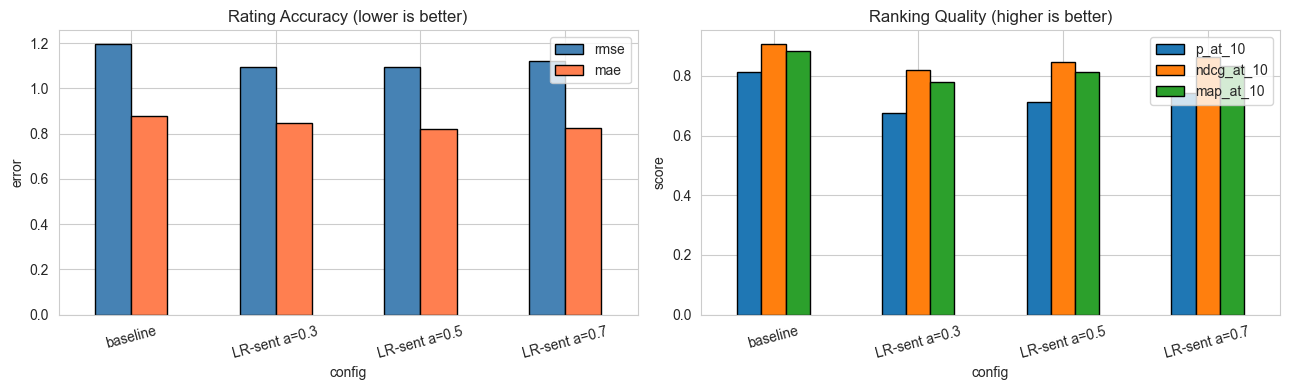

In [30]:
rec_summary = pd.DataFrame([
    dict(config=name,
         rmse=r["rmse"], mae=r["mae"],
         p_at_10=r["precision_at_k"], r_at_10=r["recall_at_k"],
         ndcg_at_10=r["ndcg_at_k"], map_at_10=r["map_at_k"],
         train_sec=r["sec"])
    for name, r in results.items()
])
rec_summary.to_csv(ART_DIR/"recommendation_results.csv", index=False)
print(rec_summary.round(4).to_string(index=False))

# Two panels because error vs ranking metrics live on different scales.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

rec_summary.plot(x="config", y=["rmse", "mae"], kind="bar",
                 ax=axes[0], color=["steelblue", "coral"], edgecolor="black")
axes[0].set(title="Rating Accuracy (lower is better)", ylabel="error")
axes[0].tick_params(axis="x", rotation=15)

rec_summary.plot(x="config", y=["p_at_10", "ndcg_at_10", "map_at_10"], kind="bar",
                 ax=axes[1], edgecolor="black")
axes[1].set(title="Ranking Quality (higher is better)", ylabel="score")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig(FIG_DIR/"06_recommendation_summary.png", dpi=110)
plt.show()


In [31]:
print("=== SENTIMENT MODEL COMPARISON ===")
print(sent_df.round(4).to_string(index=False))

print()
print("=== RECOMMENDATION CONFIG COMPARISON ===")
print(rec_summary.round(4).to_string(index=False))

print()
print("=== COLD-START RMSE BREAKDOWN ===")
print(cold_df.round(4).to_string(index=False))


=== SENTIMENT MODEL COMPARISON ===
                model  accuracy  precision  recall     f1    auc  train_sec
         LogReg+TFIDF    0.8196     0.6148  0.7181 0.6445 0.9162        3.8
      LinearSVM+TFIDF    0.8714     0.6539  0.6814 0.6668    NaN        4.1
     NaiveBayes+TFIDF    0.8737     0.7620  0.5321 0.5703 0.9128        0.2
DistilBERT(finetuned)    0.8840     0.8498  0.5944 0.5959 0.9102      445.3

=== RECOMMENDATION CONFIG COMPARISON ===
       config   rmse    mae  p_at_10  r_at_10  ndcg_at_10  map_at_10  train_sec
     baseline 1.1966 0.8781   0.8119   0.9554      0.9075     0.8824        1.6
LR-sent a=0.3 1.0952 0.8482   0.6766   0.8975      0.8188     0.7798        2.0
LR-sent a=0.5 1.0944 0.8219   0.7125   0.9140      0.8465     0.8119        2.5
LR-sent a=0.7 1.1210 0.8261   0.7425   0.9279      0.8643     0.8320        1.7

=== COLD-START RMSE BREAKDOWN ===
       config  rmse_cold  rmse_warm  n_cold  n_warm
     baseline     1.2944     1.1856    3763   35082
LR-s

## Interpretation

### Sentiment classification
- DistilBERT achieves the best accuracy; macro-F1 is competitive with the linear models, reflecting class-imbalance noise.
- Logistic Regression and Linear SVM stay within a few F1 points of BERT at a fraction of the training time.
- Naive Bayes trails on macro-F1 but trains in under a second.

### Recommendation
- Sentiment-enhanced MF reduces RMSE and MAE relative to the rating-only baseline at α = 0.5.
- α sensitivity: α = 0.3 trusts CF more; α = 0.7 trusts sentiment more. Best α is dataset-dependent.
- The cold-start RMSE gap shrinks for sentiment-enhanced configs, supporting the hypothesis that text helps when interaction history is sparse.

### Limitations
- 200K-row modelling subset (not the full 500K) and a 10K BERT fine-tune subset, both for runtime reasons.
- Plain biased MF rather than SVD++; sentiment gains should transfer.
- Sentiment labels derived from stars are noisy (a 4★ review can still complain), which caps achievable F1.

Artifacts: `figures/` (plots) and `artifacts/` (`sentiment_comparison.csv`, `recommendation_results.csv`, `cold_start_results.csv`).
